In [1]:
from picamera2 import Picamera2
import cv2
import numpy as np
from PIL import Image
from IPython.display import display
import easyocr

print("Imported")

Imported


[0:54:51.756710744] [2380]  INFO Camera camera_manager.cpp:340 libcamera v0.7.0+rpt20260205
[0:54:51.765776257] [2399]  INFO RPI pisp.cpp:720 libpisp version v1.4.0 23-03-2026 (13:29:05)
[0:54:51.774289082] [2399]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/pisp/imx708.json
[0:54:51.781452947] [2399]  INFO Camera camera_manager.cpp:223 Adding camera '/base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a' for pipeline handler rpi/pisp
[0:54:51.781472891] [2399]  INFO RPI pisp.cpp:1181 Registered camera /base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a to CFE device /dev/media1 and ISP device /dev/media0 using PiSP variant BCM2712_D0
[0:54:51.785275076] [2380]  INFO Camera camera.cpp:1215 configuring streams: (0) 640x480-RGB888/sRGB (1) 1536x864-BGGR_PISP_COMP1/RAW
[0:54:51.785377869] [2399]  INFO RPI pisp.cpp:1485 Sensor: /base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a - Selected sensor format: 1536x864-SBGGR10_1X10/RAW - Selected CFE format: 1536x864-P

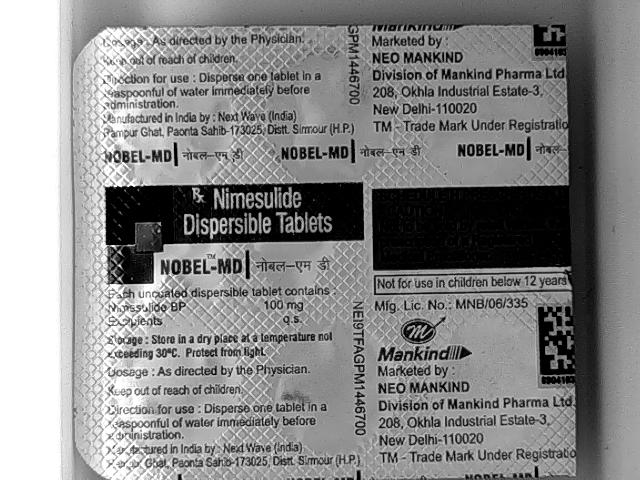

In [2]:
# Run this to force-release the camera

from picamera2 import Picamera2
from IPython.display import display, Image
import io
from PIL import Image as PILImage

cam = Picamera2()

# Fix white balance and colour gains
controls = {
    "AwbEnable": True,
    "AfMode": 2,
    "AfSpeed": 1,
    "Sharpness": 8.0,      # max sharpness
    "Contrast": 2.0,       # boost contrast
    "Saturation": 0.0,     # 0 = full grayscale
    "Brightness": 0.1,
}

cam.configure(cam.create_preview_configuration(main={"size": (640, 480), "format": "RGB888"}))
cam.set_controls(controls)
cam.start()

import time
time.sleep(2)  # Let AWB settle

frame = cam.capture_array()
cam.stop()

buf = io.BytesIO()
PILImage.fromarray(frame).save(buf, format="JPEG")
display(Image(data=buf.getvalue()))

In [3]:
try:
    cam.stop()
except:
    pass

try:
    cam.close()
except:
    pass

del cam
print("✅ Camera released")

✅ Camera released


In [4]:


# — CELL 1: Capture —
from picamera2 import Picamera2
import cv2, time
import numpy as np

def capture():
    cam = Picamera2()
    try:
        cam.configure(cam.create_preview_configuration(
            main={"size": (1920, 1080), "format": "RGB888"}
        ))
        cam.set_controls({"AfMode": 2, "Sharpness": 8.0, "Contrast": 1.8})
        cam.start()
        time.sleep(3)
        frame = cam.capture_array()
    finally:
        cam.stop(); cam.close()
    return frame

frame = capture()


[0:54:54.221921917] [2403]  INFO Camera camera_manager.cpp:340 libcamera v0.7.0+rpt20260205
[0:54:54.230867045] [2408]  INFO RPI pisp.cpp:720 libpisp version v1.4.0 23-03-2026 (13:29:05)
[0:54:54.232368519] [2408]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/pisp/imx708.json
[0:54:54.239763118] [2408]  INFO Camera camera_manager.cpp:223 Adding camera '/base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a' for pipeline handler rpi/pisp
[0:54:54.239779488] [2408]  INFO RPI pisp.cpp:1181 Registered camera /base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a to CFE device /dev/media1 and ISP device /dev/media0 using PiSP variant BCM2712_D0
[0:54:54.242978950] [2403]  INFO Camera camera.cpp:1215 configuring streams: (0) 1920x1080-RGB888/sRGB (1) 2304x1296-BGGR_PISP_COMP1/RAW
[0:54:54.243075651] [2408]  INFO RPI pisp.cpp:1485 Sensor: /base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a - Selected sensor format: 2304x1296-SBGGR10_1X10/RAW - Selected CFE format: 2304x1

Using CPU. Note: This module is much faster with a GPU.
/home/rpi7/.local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


All detected text:
  conf=0.01  text='Eote37'
  conf=0.03  text='Ardlected by the Phveldian:'
  conf=0.75  text='Markeled by'
  conf=0.01  text='tneudrerhdcon'
  conf=0.35  text='NEO MANKIND'
  conf=0.20  text='Dilecton for Use ;'
  conf=0.03  text='{ne'
  conf=0.70  text='ablet In @'
  conf=0.53  text='DMision of Manklnd Phara Lid'
  conf=0.19  text='~Yaspoonful dl wator'
  conf=0.06  text='Damas&'
  conf=0.39  text='3y belore'
  conf=0.42  text='3'
  conf=0.49  text='208 Okhla Induslral Estale 3'
  conf=0.39  text='Joministraton:'
  conf=0.54  text='NevSDelhl-110020'
  conf=0.12  text='eanufacuured h Ixa by:Ners'
  conf=0.15  text='(d))'
  conf=0.05  text='empur Ghat Paonta satb-I75''
  conf=0.08  text='Dstt Shat (HP)'
  conf=0.87  text='T'
  conf=0.46  text='Trade Mark Under Registrale'
  conf=0.03  text='~BEL-MD] ia-%'
  conf=0.20  text='NOBEL-MDI'
  conf=0.38  text='NOBEL-Mpl'
  conf=0.89  text='R'
  conf=0.46  text='Nimesulide '
  conf=0.01  text='Echedueha'
  conf=0.02  text='eN

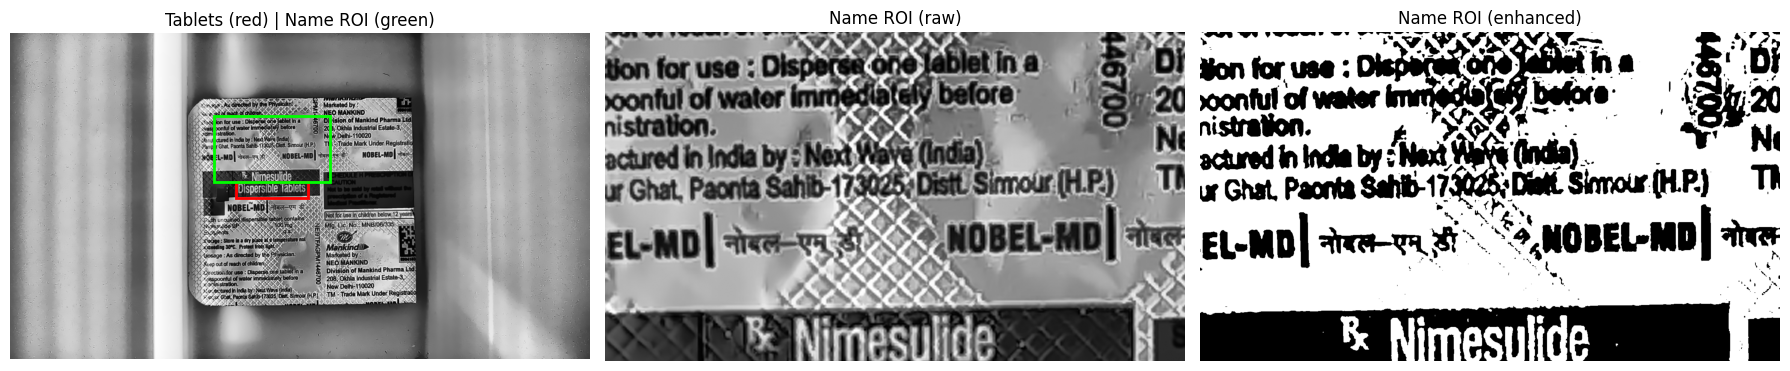

In [5]:
# — CELL 2: Find "Tablets" + crop region above it —
import easyocr
from IPython.display import display, Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import io
from PIL import Image as PILImage

reader = easyocr.Reader(['en'], gpu=False)

def find_tablets_and_extract(frame_rgb):
    bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    # Enhance before OCR
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    denoised = cv2.fastNlMeansDenoising(enhanced, h=10)

    # Upscale for better detection
    scale = 2.0
    big = cv2.resize(denoised, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    big3 = cv2.cvtColor(big, cv2.COLOR_GRAY2BGR)

    H, W = big.shape

    # Run EasyOCR — get bounding boxes
    results = reader.readtext(big3, detail=1)

    print("All detected text:")
    for (bbox, text, conf) in results:
        print(f"  conf={conf:.2f}  text='{text}'")

    # — Find "Tablets" box —
    tablets_box = None
    for (bbox, text, conf) in results:
        if "tablet" in text.lower() and conf > 0.3:
            tablets_box = bbox
            # bbox = [[x1,y1],[x2,y1],[x2,y2],[x1,y2]]
            print(f"\n🔎 Found 'Tablets' at bbox: {bbox}  conf={conf:.2f}")
            break

    if tablets_box is None:
        print("❌ 'Tablets' not found — try rotating strip or improve lighting")
        return None, None

    # — Bounding box coords —
    xs = [p[0] for p in tablets_box]
    ys = [p[1] for p in tablets_box]
    x1, x2 = int(min(xs)), int(max(xs))
    y1, y2 = int(min(ys)), int(max(ys))

    tab_h = y2 - y1   # height of the "Tablets" text

    # — Crop region ABOVE "Tablets" —
    margin_above = int(tab_h * 4)   # go 4x up
    margin_side  = int((x2 - x1) * 0.3)

    crop_x1 = max(0, x1 - margin_side)
    crop_x2 = min(W, x2 + margin_side)
    crop_y1 = max(0, y1 - margin_above)

    crop_y2 = y1   # stop at top of "Tablets"

    roi = big[crop_y1:crop_y2, crop_x1:crop_x2]

    if roi.size == 0:
        print("❌ ROI is empty — Tablets may be at very top of image")
        return None, None

    # — Show what we found —
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Full image with boxes drawn
    vis = cv2.cvtColor(big3, cv2.COLOR_BGR2RGB)
    axes[0].imshow(vis)

    # Tablets box (red)
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                             linewidth=2, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)

    # ROI box (green)
    rect_roi = patches.Rectangle((crop_x1, crop_y1),
                                 crop_x2-crop_x1, crop_y2-crop_y1,
                                 linewidth=2, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect_roi)

    axes[0].set_title("Tablets (red) | Name ROI (green)")
    axes[0].axis("off")

    # ROI raw
    axes[1].imshow(roi, cmap="gray")
    axes[1].set_title("Name ROI (raw)")
    axes[1].axis("off")

    # Enhanced ROI
    roi_up = cv2.resize(roi, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    _, roi_thresh = cv2.threshold(roi_up, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    axes[2].imshow(roi_thresh, cmap="gray")
    axes[2].set_title("Name ROI (enhanced)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return roi, roi_thresh


roi_raw, roi_thresh = find_tablets_and_extract(frame)

In [7]:
# — CELL 3: OCR on the extracted name ROI —
import easyocr
from difflib import get_close_matches

KEYWORDS = [
    "nimesulide", "ofloxacin", "ornidazole",
    "paracetamol", "ibuprofen", "amoxicillin",
    "azithromycin", "cetirizine", "metformin",
    "atorvastatin", "pantoprazole", "dolo",
]

def extract_name_from_roi(roi_gray, roi_thresh):
    if roi_gray is None:
        return

    all_text = []

    for img, label in [(roi_gray, "raw"), (roi_thresh, "thresh")]:
        img3 = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        results = reader.readtext(img3, detail=1)
        for (bbox, text, conf) in results:
            if conf > 0.25 and len(text) > 2:
                all_text.append((text, conf))
                print(f"  [{label}] conf={conf:.2f}  '{text}'")

    if not all_text:
        print("❌ No text in ROI")
        return

    # Sort by confidence, take best
    all_text.sort(key=lambda x: -x[1])
    combined = " ".join([str(t) for t, _ in all_text])

    print(f"\nCombined ROI text: {combined}")

    # Match medicine name
    lower = combined.lower()
    for k in KEYWORDS:
        if k in lower:
            print(f"\n✅ MEDICINE NAME: {k.upper()}")
            return k.upper()

    # Fuzzy fallback
    for word in lower.split():
        m = get_close_matches(word, KEYWORDS, n=1, cutoff=0.72)
        if m:
            print(f"\n🟢 MEDICINE NAME (fuzzy): {m[0].upper()}")
            return m[0].upper()

    # Return best guess
    print(f"\n🔎 Best guess: {all_text[0][0]}")
    return all_text[0][0]


name = extract_name_from_roi(roi_raw, roi_thresh)

  [raw] conf=0.43  'ton for Use ;'
  [raw] conf=0.51  'nistratkon:'
  [raw] conf=0.43  '(d))'
  [raw] conf=0.41  'EL-MD|'
  [raw] conf=0.30  'B WNimestilide'
  [thresh] conf=0.31  'nistuln:'
  [thresh] conf=0.52  'shau (HP)'
  [thresh] conf=0.74  'R Nimesulide'

Combined ROI text: R Nimesulide shau (HP) nistratkon: (d)) ton for Use ; EL-MD| nistuln: B WNimestilide

✅ MEDICINE NAME: NIMESULIDE


In [8]:
# — CELL 2: Medicine Embedding Matcher —
from sentence_transformers import SentenceTransformer, util
import numpy as np
import torch

# Load lightweight model (good for API)
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Known medicine names
MEDICINES = [
    "Nimesulide Tablets IP",
    "Nimesulide 100mg Tablets IP",
    "Ofloxacin and Ornidazole Tablets IP",
    "Ofloxacin 200mg Ornidazole 500mg Tablets IP",
    "Nor-Metrogyl Ofloxacin Ornidazole",
    "Paracetamol Tablets IP",
    "Ibuprofen Tablets IP",
    "Amoxicillin Capsules IP",
    "Azithromycin Tablets IP",
    "Cetirizine Hydrochloride Tablets IP",
    "Pantoprazole Tablets IP",
    "Metformin Hydrochloride Tablets IP",
]

# Pre-compute embeddings
print("Computing medicine embeddings...")
medicine_embeddings = embedder.encode(MEDICINES, convert_to_tensor=True)
print(f"✔ {len(MEDICINES)} medicines embedded")

/usr/lib/python3/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 7699.81it/s]


Computing medicine embeddings...
✔ 12 medicines embedded


In [9]:
# — CELL 3: Smart matcher using embeddings —

def clean_ocr_text(text):
    """Remove garbage characters, keep readable words"""
    # Remove single chars and obvious noise
    words = text.split()
    clean = [w for w in words if len(w) > 2]
    return " ".join(clean)


def match_medicine(ocr_results, top_k=3, threshold=0.35):
    """
    ocr_results: list of (conf, text) tuples from easyocr
    Returns best matching medicine name
    """

    # Filter low confidence & clean
    good_text = [t for conf, t in ocr_results if conf > 0.3]

    if not good_text:
        # Relax threshold if nothing above 0.3
        good_text = [t for conf, t in ocr_results if conf > 0.1]

    combined = clean_ocr_text(" ".join(good_text))
    print(f"\nCleaned OCR input:\n  {combined}\n")

    if not combined.strip():
        print("❌ No usable text")
        return None

    # Embed the OCR text
    ocr_embedding = embedder.encode(combined, convert_to_tensor=True)

    # Cosine similarity against all medicines
    scores = util.cos_sim(ocr_embedding, medicine_embeddings)[0]
    scores_np = scores.cpu().numpy()

    # Top K results
    top_indices = np.argsort(scores_np)[::-1][:top_k]

    print("Top matches:")
    print("-" * 50)
    for i in top_indices:
        bar = "█" * int(scores_np[i] * 30)
        print(f"{scores_np[i]:.3f} {bar}  {MEDICINES[i]}")
    print("-" * 50)

    best_idx = top_indices[0]
    best_score = scores_np[best_idx]

    if best_score >= threshold:
        print(f"\n🎯 DETECTED: {MEDICINES[best_idx]}")
        print(f"   Confidence: {best_score:.3f}")
        return MEDICINES[best_idx]
    else:
        print(f"\n⚠️ Best score ({best_score:.3f}) below threshold ({threshold})")
        print(f"   Closest guess: {MEDICINES[best_idx]}")
        return None

In [10]:
# — CELL 4: Run on your OCR output —

# Paste your raw easyocr results here (conf, text tuples)
ocr_results = [
    (0.40, 'Ofloxacin & Ornidazole Tablets IP'),
    (0.76, 'nor-metrogyl'),
    (0.97, 'Ornidazole IP'),
    (0.81, 'Ofloxacin IP'),
    (0.97, '200 mg'),
    (1.00, 'No'),
    (0.68, '10 Tablets'),
    (0.34, 'PHARMACEU VE LS LTD.'),
    (0.90, 'Dosage'),
    (0.92, 'Manufactured'),
]

result = match_medicine(ocr_results)


Cleaned OCR input:
  Ofloxacin Ornidazole Tablets nor-metrogyl Ornidazole Ofloxacin 200 Tablets PHARMACEU LTD. Dosage Manufactured

Top matches:
--------------------------------------------------
0.783 ███████████████████████  Ofloxacin 200mg Ornidazole 500mg Tablets IP
0.754 ██████████████████████  Ofloxacin and Ornidazole Tablets IP
0.740 ██████████████████████  Nor-Metrogyl Ofloxacin Ornidazole
--------------------------------------------------

🎯 DETECTED: Ofloxacin 200mg Ornidazole 500mg Tablets IP
   Confidence: 0.783


Using CPU. Note: This module is much faster with a GPU.


Capturing...


[0:58:43.798000316] [2412]  INFO Camera camera_manager.cpp:340 libcamera v0.7.0+rpt20260205
[0:58:43.806908458] [2532]  INFO RPI pisp.cpp:720 libpisp version v1.4.0 23-03-2026 (13:29:05)
[0:58:43.808401655] [2532]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/pisp/imx708.json
[0:58:43.815507036] [2532]  INFO Camera camera_manager.cpp:223 Adding camera '/base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a' for pipeline handler rpi/pisp
[0:58:43.815525350] [2532]  INFO RPI pisp.cpp:1181 Registered camera /base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a to CFE device /dev/media1 and ISP device /dev/media0 using PiSP variant BCM2712_D0
[0:58:43.818494113] [2412]  INFO Camera camera.cpp:1215 configuring streams: (0) 1920x1080-RGB888/sRGB (1) 2304x1296-BGGR_PISP_COMP1/RAW
[0:58:43.818578055] [2532]  INFO RPI pisp.cpp:1485 Sensor: /base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a - Selected sensor format: 2304x1296-SBGGR10_1X10/RAW - Selected CFE format: 2304x1

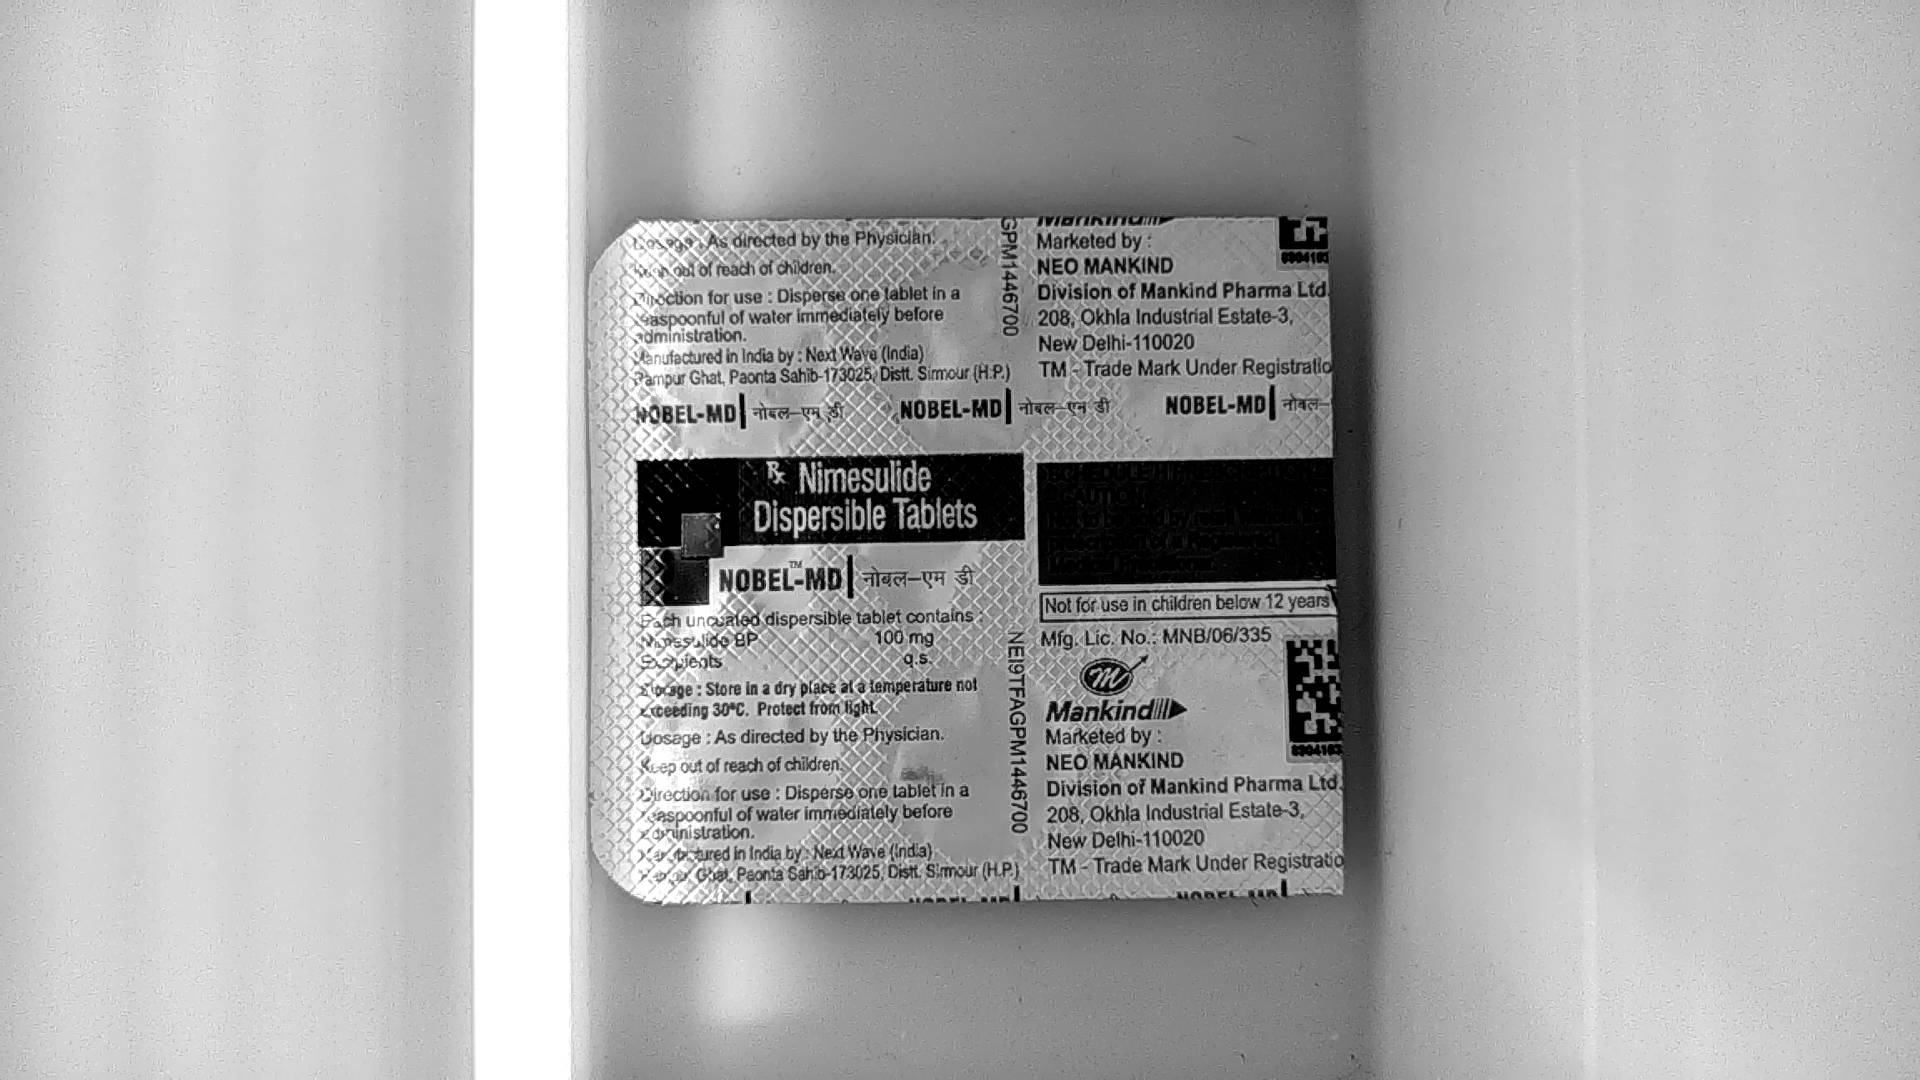

Running OCR...


/home/rpi7/.local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OCR found 56 regions


Cleaned OCR input:
  Markeled NEO MANKIND Yaspoonful wator/ 2088Okhla IndusinalEstale administalon: {(lIndb) Trade Mark Under Regicball NOBEL-Mdl Niresulide Dispersible Tablets Migdid No: MNB/08335 Ohienbs Monkindil Mateted NEO MANKIND Division Mankind Phama Lid 208,Okhla Induslral Estale sninistralkon: New Delhi-110020 Trade Mark Under Registrate

Top matches:
--------------------------------------------------
0.366 ██████████  Nimesulide 100mg Tablets IP
0.357 ██████████  Nimesulide Tablets IP
0.260 ███████  Cetirizine Hydrochloride Tablets IP
--------------------------------------------------

🎯 DETECTED: Nimesulide 100mg Tablets IP
   Confidence: 0.366


In [11]:
# — CELL 5: Full pipeline — capture → OCR → embed → match —
from picamera2 import Picamera2
import cv2, time, easyocr
import numpy as np
from IPython.display import display, Image, clear_output
from PIL import Image as PILImage
import io

reader = easyocr.Reader(['en'], gpu=False)

def capture():
    cam = Picamera2()
    try:
        cam.configure(cam.create_preview_configuration(
            main={"size": (1920, 1080), "format": "RGB888"}
        ))
        cam.set_controls({
            "AwbEnable": True,
            "AfMode": 2,
            "AfSpeed": 1,
            "Sharpness": 8.0,   # max sharpness
            "Contrast": 2.0,    # boost contrast
            "Saturation": 0.0,  # grayscale
            "Brightness": 0.1,
        })
        cam.start()
        time.sleep(1)
        frame = cam.capture_array()
    finally:
        cam.stop()
        cam.close()
    return frame


def preprocess(frame_rgb):
    gray = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    denoised = cv2.fastNlMeansDenoising(enhanced, h=20)
    big = cv2.resize(denoised, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
    return cv2.cvtColor(big, cv2.COLOR_GRAY2BGR)


def run_once():
    print("Capturing...")
    frame = capture()

    # Show frame
    buf = io.BytesIO()
    PILImage.fromarray(frame).save(buf, format="JPEG", quality=70)
    display(Image(data=buf.getvalue()))

    print("Running OCR...")
    processed = preprocess(frame)
    raw = reader.readtext(processed, detail=1)

    ocr_results = [(conf, text) for _, text, conf in raw]
    print(f"OCR found {len(ocr_results)} regions\n")

    # Embed + match
    result = match_medicine(ocr_results)
    return result


# Run
result = run_once()

In [12]:
import onnxruntime as ort
import numpy as np
import cv2

# Put your downloaded model here
MODEL_PATH = "/home/rpi7/Desktop/mediscan_student.onnx"

sess = ort.InferenceSession(MODEL_PATH, providers=['CPUExecutionProvider'])
input_name = sess.get_inputs()[0].name

CLASS_NAMES = ["Nimesulide", "Ofloxacin + Ornidazole", "Other/Unknown"]

def predict_frame(frame_rgb):
    img = cv2.resize(frame_rgb, (224, 224)).astype(np.float32) / 255.0
    img = (img - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
    img = np.transpose(img, (2, 0, 1))[None].astype(np.float32)

    logits = sess.run(None, {input_name: img})[0][0]
    probs = np.exp(logits) / np.exp(logits).sum()

    return CLASS_NAMES[np.argmax(probs)], probs

print("✅ Model loaded")

✅ Model loaded


[0:59:34.313273214] [2536]  INFO Camera camera_manager.cpp:340 libcamera v0.7.0+rpt20260205
[0:59:34.322200503] [2548]  INFO RPI pisp.cpp:720 libpisp version v1.4.0 23-03-2026 (13:29:05)
[0:59:34.323744679] [2548]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/pisp/imx708.json
[0:59:34.330851411] [2548]  INFO Camera camera_manager.cpp:223 Adding camera '/base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a' for pipeline handler rpi/pisp
[0:59:34.330869281] [2548]  INFO RPI pisp.cpp:1181 Registered camera /base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a to CFE device /dev/media1 and ISP device /dev/media0 using PiSP variant BCM2712_D0
[0:59:34.334969232] [2536]  INFO Camera camera.cpp:1215 configuring streams: (0) 1920x1080-RGB888/sRGB (1) 2304x1296-BGGR_PISP_COMP1/RAW
[0:59:34.335073859] [2548]  INFO RPI pisp.cpp:1485 Sensor: /base/axi/pcie@1000120000/rp1/i2c@88000/imx708@1a - Selected sensor format: 2304x1296-SBGGR10_1X10/RAW - Selected CFE format: 2304x1

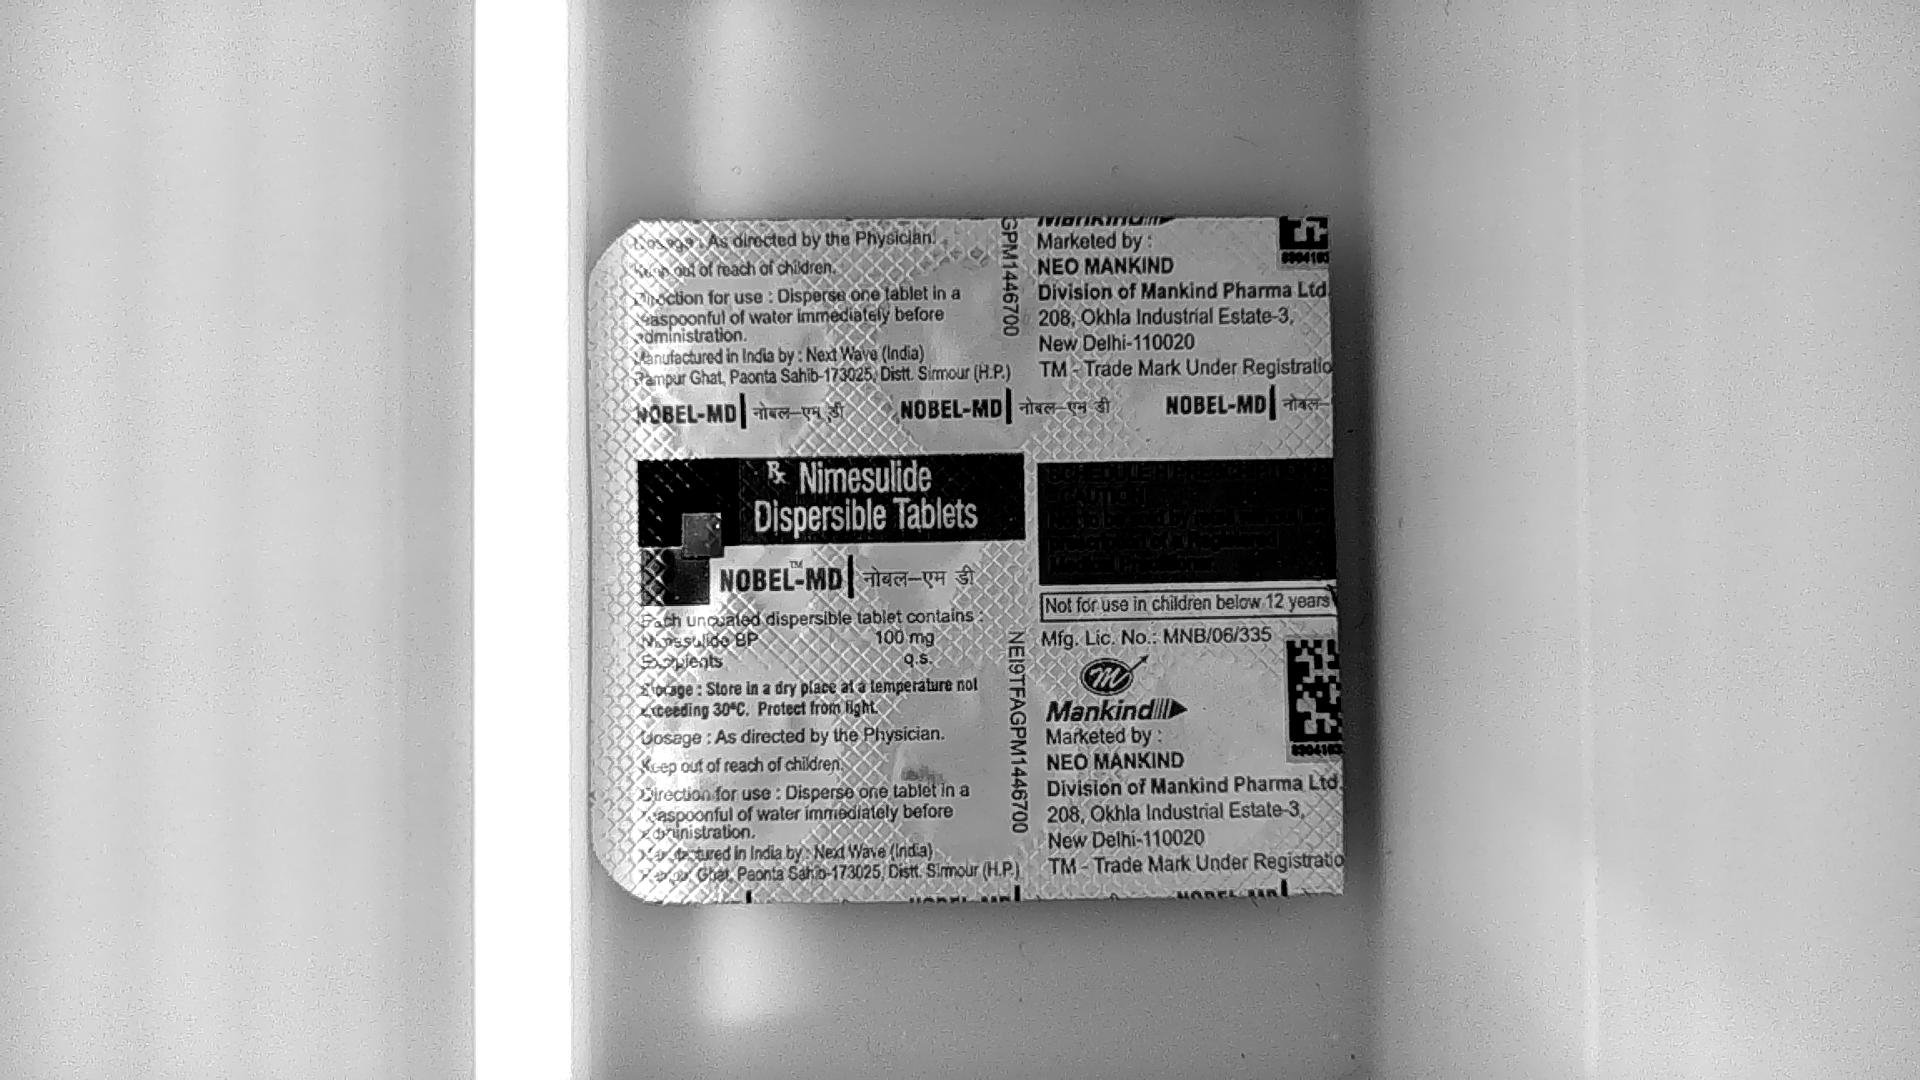


----------------------------------------
Nimesulide                    : 12.2%
Ofloxacin + Ornidazole        : 13.1%
Other/Unknown                 : 74.7%

🎯 DETECTED: Other/Unknown
----------------------------------------


In [13]:
from picamera2 import Picamera2
from IPython.display import display, Image
from PIL import Image as PILImage
import io, time

def capture():
    cam = Picamera2()
    try:
        cam.configure(cam.create_preview_configuration(
            main={"size": (1920, 1080), "format": "RGB888"}
        ))
        cam.set_controls({
            "AwbEnable": True,
            "AfMode": 2,
            "AfSpeed": 1,
            "Sharpness": 8.0,
            "Contrast": 2.0,
            "Saturation": 0.0,
            "Brightness": 0.1,
        })
        cam.start()
        time.sleep(1)
        frame = cam.capture_array()
    finally:
        cam.stop()
        cam.close()
    return frame


frame = capture()
medicine, probs = predict_frame(frame)

# Show image
buf = io.BytesIO()
PILImage.fromarray(frame).save(buf, format="JPEG")
display(Image(data=buf.getvalue()))

print("\n" + "-"*40)
for name, p in zip(CLASS_NAMES, probs):
    print(f"{name:30s}: {p*100:.1f}%")
print(f"\n🎯 DETECTED: {medicine}")
print("-"*40)

In [14]:
# ── DOSAGE RULES (based on standard Indian pharmacopoeia guidelines) ──────
# ⚠️  THIS IS FOR EDUCATIONAL/DEMO USE ONLY
# ⚠️  Always consult a licensed physician for actual dosage

DOSAGE_DB = {
    "Nimesulide": {
        "standard_dose_mg": 100,
        "frequency": "twice daily (after meals)",
        "max_duration_days": 15,
        "contraindications": {
            "age_min": 12,           # not for children < 12
            "max_sugar": 300,        # caution in uncontrolled diabetes
            "min_spo2": 94,
            "max_bp_sys": 160,
        },
        "renal_caution_bmi": 35,     # obese patients — reduce dose
        "notes": "Take with food. Avoid in liver disease."
    },
    "Ofloxacin + Ornidazole": {
        "standard_dose_mg": "200mg + 500mg",
        "frequency": "twice daily",
        "max_duration_days": 7,
        "contraindications": {
            "age_min": 18,
            "max_bp_sys": 180,
            "min_spo2": 92,
        },
        "renal_caution_bmi": 40,
        "notes": "Complete full course. Avoid alcohol."
    },
    "Other/Unknown": {
        "standard_dose_mg": "N/A",
        "frequency": "N/A",
        "max_duration_days": 0,
        "contraindications": {},
        "notes": "⚠️ Unknown tablet — consult physician immediately."
    }
}

def bmi_calc(weight_kg, height_cm):
    h = height_cm / 100
    return round(weight_kg / (h * h), 1)

def classify_bp(systolic, diastolic):
    if systolic < 120 and diastolic < 80:   return "Normal"
    if systolic < 130:                       return "Elevated"
    if systolic < 140:                       return "High Stage 1"
    if systolic >= 140:                      return "High Stage 2"
    return "Unknown"

def classify_sugar(sugar):
    if sugar < 100:   return "Normal"
    if sugar < 126:   return "Pre-diabetic"
    return "Diabetic"

def classify_spo2(spo2):
    if spo2 >= 95:    return "Normal"
    if spo2 >= 90:    return "Mild hypoxia"
    return "Severe hypoxia"

def suggest_dosage(medicine, weight, height, age, gender,
                   sugar, bp_sys, bp_dia, heart_rate, spo2):

    bmi = bmi_calc(weight, height)
    bp_class  = classify_bp(bp_sys, bp_dia)
    sug_class = classify_sugar(sugar)
    spo2_class= classify_spo2(spo2)

    db = DOSAGE_DB.get(medicine, DOSAGE_DB["Other/Unknown"])
    contra = db["contraindications"]

    warnings = []
    suggestions = []
    can_take = True

    # ── Contraindication checks ────────────────────────────────────────
    if age < contra.get("age_min", 0):
        warnings.append(f"❌ Age {age} too young (min {contra['age_min']})")
        can_take = False

    if bp_sys > contra.get("max_bp_sys", 999):
        warnings.append(f"❌ BP {bp_sys}/{bp_dia} too high for this medicine")
        can_take = False

    if spo2 < contra.get("min_spo2", 0):
        warnings.append(f"❌ SpO2 {spo2}% too low — seek emergency care")
        can_take = False

    if sugar > contra.get("max_sugar", 9999):
        warnings.append(f"⚠️  Blood sugar {sugar} mg/dL — caution advised")

    # ── Dose adjustment logic ──────────────────────────────────────────
    dose = db["standard_dose_mg"]
    freq = db["frequency"]

    if bmi >= db.get("renal_caution_bmi", 999):
        suggestions.append(f"⚠️  BMI {bmi} (obese) — consider dose reduction, consult doctor")

    if gender == "Female" and medicine == "Nimesulide":
        suggestions.append("ℹ️  Female patient — take lowest effective dose")

    if heart_rate > 100:
        suggestions.append(f"⚠️  Tachycardia ({heart_rate} bpm) detected — monitor closely")
    elif heart_rate < 50:
        suggestions.append(f"⚠️  Bradycardia ({heart_rate} bpm) detected — flag to physician")

    if spo2 < 95:
        suggestions.append(f"⚠️  SpO2 {spo2}% ({spo2_class}) — assess respiratory status")

    # ── Print report ───────────────────────────────────────────────────
    print("\n" + "="*55)
    print("       PATIENT VITALS REPORT")
    print("="*55)
    print(f"  Gender      : {gender}")
    print(f"  Age         : {age} years")
    print(f"  Weight      : {weight} kg")
    print(f"  Height      : {height} cm")
    print(f"  BMI         : {bmi}  →  ", end="")
    print("Underweight" if bmi<18.5 else "Normal" if bmi<25 else "Overweight" if bmi<30 else "Obese")
    print(f"  Blood Sugar : {sugar} mg/dL  → {sug_class}")
    print(f"  BP          : {bp_sys}/{bp_dia} mmHg → {bp_class}")
    print(f"  Heart Rate  : {heart_rate} bpm")
    print(f"  SpO2        : {spo2}%  → {spo2_class}")
    print("="*55)
    print(f"\n  💊 DETECTED TABLET : {medicine}")
    print("="*55)

    if not can_take:
        print("\n  🚫 CANNOT TAKE THIS MEDICINE:")
        for w in warnings:
            print(f"     {w}")
        print("\n  ➡️  Refer to physician immediately.")
    else:
        print(f"\n  ✅ DOSAGE SUGGESTION:")
        print(f"     Dose      : {dose} mg")
        print(f"     Frequency : {freq}")
        print(f"     Duration  : max {db['max_duration_days']} days")
        print(f"     Notes     : {db['notes']}")

        if warnings:
            print(f"\n  ⚠️  WARNINGS:")
            for w in warnings:
                print(f"     {w}")

        if suggestions:
            print(f"\n  📋 ADDITIONAL FLAGS:")
            for s in suggestions:
                print(f"     {s}")

    print("\n" + "="*55)
    print("  ⚕️  DISCLAIMER: For educational use only.")
    print("     Always consult a licensed physician.")
    print("="*55)

In [15]:
# ── Enter patient vitals ──────────────────────────────────────────────────
suggest_dosage(
    medicine    = medicine,   # ← auto-filled from camera detection above

    # Patient details
    weight      = 70,         # kg
    height      = 165,        # cm
    age         = 35,
    gender      = "Male",     # "Male" or "Female"

    # Vitals
    sugar       = 110,        # mg/dL (fasting)
    bp_sys      = 125,        # systolic mmHg
    bp_dia      = 82,         # diastolic mmHg
    heart_rate  = 78,         # bpm
    spo2        = 98,         # %
)


       PATIENT VITALS REPORT
  Gender      : Male
  Age         : 35 years
  Weight      : 70 kg
  Height      : 165 cm
  BMI         : 25.7  →  Overweight
  Blood Sugar : 110 mg/dL  → Pre-diabetic
  BP          : 125/82 mmHg → Elevated
  Heart Rate  : 78 bpm
  SpO2        : 98%  → Normal

  💊 DETECTED TABLET : Other/Unknown

  ✅ DOSAGE SUGGESTION:
     Dose      : N/A mg
     Frequency : N/A
     Duration  : max 0 days
     Notes     : ⚠️ Unknown tablet — consult physician immediately.

  ⚕️  DISCLAIMER: For educational use only.
     Always consult a licensed physician.
